In [3]:
# general 
import scipy as sp
import pickle
from tqdm.notebook import tqdm
import json
import getdist
from getdist import plots, MCSamples
import matplotlib.pyplot as plt

# density estimation 
from sbi.inference import NPE, NLE
import torch
from sbi.analysis import pairplot
from sbi.analysis import plot_summary
from sbi.utils import BoxUniform
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot

/Users/brian/Library/CloudStorage/OneDrive-Personal/Documents/UCL/Projects/sbi-compression/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import multiprocessing
num_cores = multiprocessing.cpu_count()
print(f'Number of CPU cores available: {num_cores}')

if torch.cuda.is_available():
    device = 'cuda'
    print(f'Device: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = 'mps'
    print(f'Device: MPS')    
else:
    device = 'cpu'
    print('Device: CPU')

Number of CPU cores available: 14
Device: MPS


The dimension of the parameter datset is (66295, 6)
The dimension of the compressed data dataset is (66295, 6)
The dimension of the parameter datset is (66295, 6)
The dimension of the compressed data dataset is (66295, 6)
The dimension of the parameter datset is (66295, 6)
The dimension of the compressed data dataset is (66295, 6)


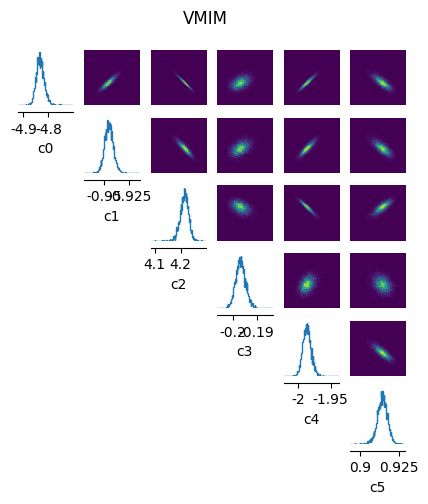

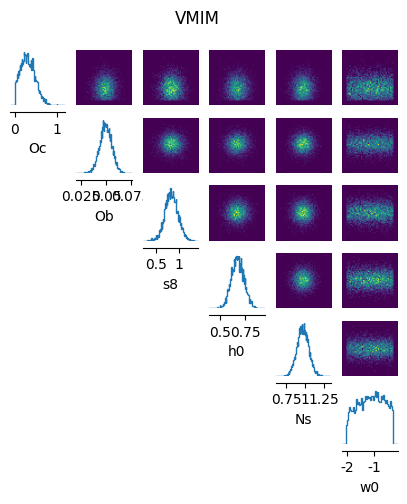

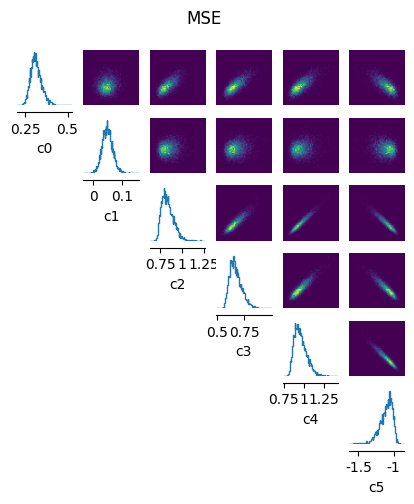

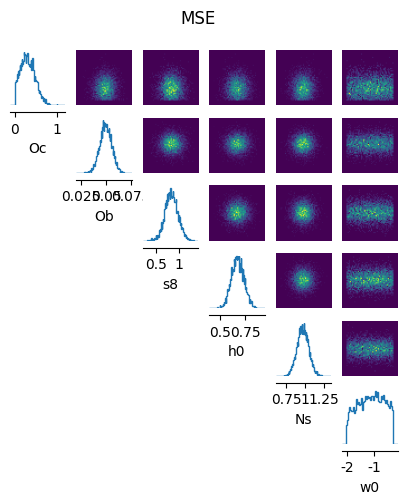

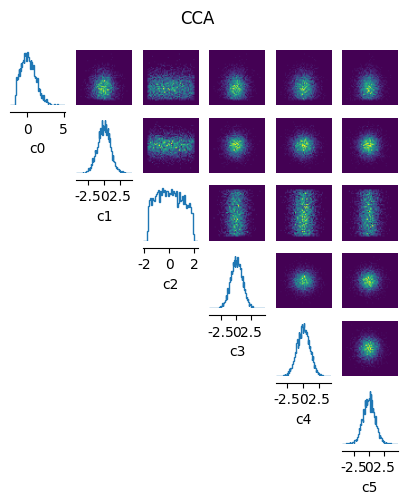

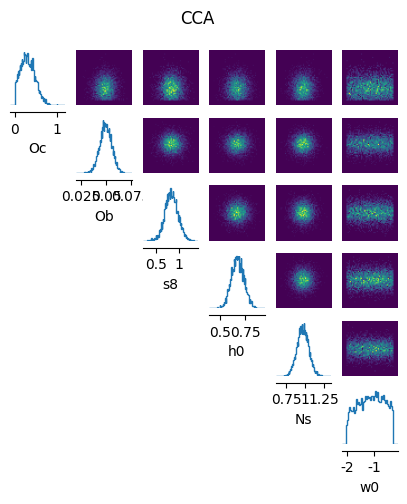

In [21]:
compression_types = ["VMIM","MSE","CCA"]
compression_directories = [
    "compressed_data/VMIM_4transforms_8bins_min-3.0_max3.0.pkl",
    "compressed_data/MSE_sbi_lens.pkl",
    "compressed_data/CCA_sbi_lens.pkl",
    ]
gt_list = []
cd_list = []
for i,c in enumerate(compression_types):
    with open(compression_directories[i], 'rb') as f:
        load = pickle.load(f)
        gt = load["ground_truth"]
        cd = load["compressed_data"]
        print('The dimension of the parameter datset is', gt.shape)
        print('The dimension of the compressed data dataset is', cd.shape)
        gt_list.append(gt)
        cd_list.append(cd)

param_names = ['Oc','Ob','s8','h0','Ns','w0']
for i,(gt,cd) in enumerate(zip(gt_list,cd_list)):
    _ = pairplot(cd, figsize=(5,5), labels=['c0','c1','c2','c3','c4','c5'])
    plt.suptitle(compression_types[i])
    _ = pairplot(gt, figsize=(5,5), labels=param_names)
    plt.suptitle(compression_types[i])

        

parameter samples <class 'torch.Tensor'> torch.Size([66295, 6]) cls samples <class 'torch.Tensor'> torch.Size([66295, 6])
Density estimation model: <sbi.inference.trainers.nle.nle_a.NLE_A object at 0x1261257b0>


/Users/brian/Library/CloudStorage/OneDrive-Personal/Documents/UCL/Projects/sbi-compression/.venv/lib/python3.13/site-packages/sbi/inference/trainers/base.py:303: UserWarning: Data x has device 'cpu'. Moving x to the data_device 'mps'. Training will proceed on device 'mps'.
  theta, x = validate_theta_and_x(
/Users/brian/Library/CloudStorage/OneDrive-Personal/Documents/UCL/Projects/sbi-compression/.venv/lib/python3.13/site-packages/sbi/inference/trainers/base.py:303: UserWarning: Parameters theta has device 'cpu'. Moving theta to the data_device 'mps'. Training will proceed on device 'mps'.
  theta, x = validate_theta_and_x(


 Training neural network. Epochs trained: 78

 Neural network successfully converged after 79 epochs.

/var/folders/yt/ybnb7bw10vj2y7213d6y2l_00000gn/T/ipykernel_44660/2114730530.py:22: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tracker instance (instead of appending to the current one).
  pickle.dump(nle, f)
/Users/brian/Library/CloudStorage/OneDrive-Personal/Documents/UCL/Projects/sbi-compression/.venv/lib/python3.13/site-packages/sbi/inference/potentials/likelihood_based_potential.py:52: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(
/Users/brian/Library/CloudStorage/OneDrive-Personal/Documents/UCL/Projects/sbi-compression/.venv/lib/python3.13/site-packages/sbi/utils/sbiutils.py:879: User

Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
The compressed observation is tensor([-0.1912, -0.8183,  1.1921,  0.7677, -1.1573,  0.4193])


Running vectorized MCMC with 20 chains: 100%|██████████| 6000/6000 [05:38<00:00, 17.74it/s]


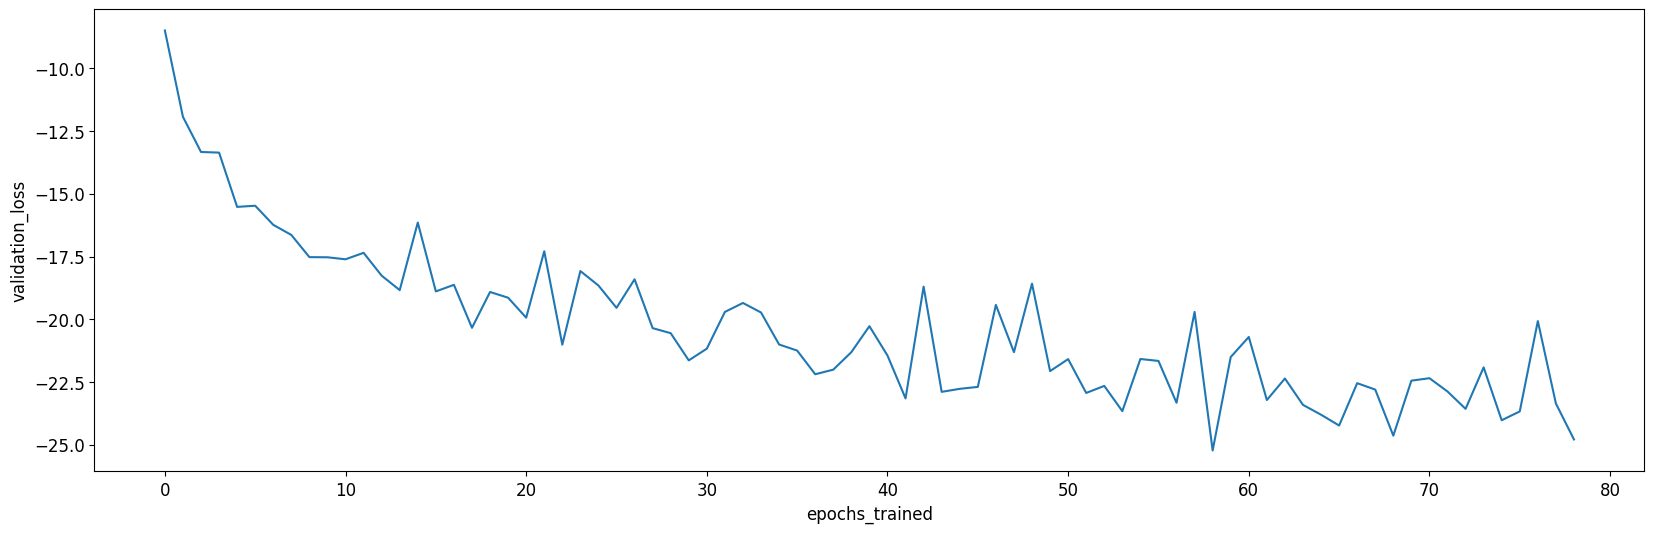

In [26]:
i = 2
gt = gt_list[i]
cd = cd_list[i]

nle = NLE(density_estimator="nsf", device='mps')

# Convert parameter and cls data to tensors for training
gt = torch.tensor(gt, dtype=torch.float32)
cd = torch.tensor(cd, dtype=torch.float32)
# Check whether the trainig data is of correct shape and network has been instantiated
print('parameter samples', type(gt), gt.shape, 'cls samples', type(cd), cd.shape)
print('Density estimation model:', nle)

nle = nle.append_simulations(gt, cd, data_device='mps')
nle.train(
    training_batch_size=512,
    learning_rate=8e-4,
)

_ = plot_summary(nle)
with open(f"trained_models/NLE_{compression_types[i]}_sbi_lens.pkl", "wb") as f:
    pickle.dump(nle, f)

from torch import Tensor
from torch.distributions import Normal, Distribution
from sbi.utils import MultipleIndependent

class TruncatedNormal(Distribution):
    def __init__(
            self,
            mu: Tensor,
            sigma: Tensor,
            lower: Tensor = None,
            upper: Tensor = None,
        ):
        self.mu = mu
        self.sigma = sigma
        if lower == None:
            self.lower = torch.tensor(float('-inf'), device=mu.device)
        else: 
            self.lower = lower
        if upper == None:
            self.upper = torch.tensor(float('inf'), device=mu.device)
        else: 
            self.upper = upper
        super().__init__(batch_shape=torch.Size([]), event_shape=mu.shape)
        self.dist = Normal(mu, sigma)
        self.log_Z = torch.log(self.dist.cdf(self.upper) - self.dist.cdf(self.lower)) # Truncation normalisation

    def sample(self, sample_shape=torch.Size([])):
        # Reject samples if outside of trauncation bounds
        num_samples = torch.Size(sample_shape).numel() if sample_shape else 1
        samples = []
        while len(samples) < num_samples:
            s = self.dist.sample((num_samples,))
            mask = (s>=self.lower) & (s<=self.upper)
            # If it's multi-dimensional data, like a 2D coordinate [x, y], ensuree that both x and y are inside the bounds. If even one coordinate is out of bounds, the whole point is rejected
            valid = s[mask.all(dim=-1)] if s.dim()>1 else s[mask] 
            samples.extend(valid)
        final_samples = torch.stack(samples[:num_samples]).reshape(sample_shape + self.mu.shape)
        return final_samples
    
    def log_prob(self, values):
        lp = self.dist.log_prob(values)
        lp = lp - self.log_Z
        out_of_bounds = (values < self.lower) | (values > self.upper)
        if values.dim() > 1:
            # For multivariate, it's out of bounds if ANY dimension is out
            out_of_bounds = out_of_bounds.any(dim=-1, keepdim=True)
        lp = torch.where(out_of_bounds, torch.tensor(float('-inf'), device=lp.device), lp)
        return lp


with open(f"trained_models/NLE_{compression_types[i]}_sbi_lens.pkl", "rb") as f:
    nle = pickle.load(f)

prior = MultipleIndependent([
    TruncatedNormal(torch.tensor([0.2664]).to(device), 
                    torch.tensor([0.2]).to(device), 
                    lower=torch.tensor([0.0]).to(device)
                    ),
    Normal(torch.tensor([0.0492]).to(device), 
           torch.tensor([0.006]).to(device)
           ),
    Normal(torch.tensor([0.831]).to(device), 
           torch.tensor([0.14]).to(device)
           ),
    Normal(torch.tensor([0.6727]).to(device), 
           torch.tensor([0.063]).to(device)
           ),
    Normal(torch.tensor([0.9645]).to(device), 
           torch.tensor([0.08]).to(device)
           ),
    TruncatedNormal(torch.tensor([-1.0]).to(device), 
                    torch.tensor([0.9]).to(device), 
                    lower=torch.tensor([-2.0]).to(device), 
                    upper=torch.tensor([-0.3]).to(device)
                    ),
    ],
    device=device)

posterior = nle.build_posterior(prior=prior)
print(posterior)
cd_obs = torch.tensor(cd[42,:], dtype=torch.float32)
print('The compressed observation is', cd_obs)
n_samples = 1000
samples = posterior.sample((n_samples,), x=cd_obs)

with open(f"posterior_samples/NLE_{compression_types[i]}_posterior_{n_samples}samples.pkl", "wb") as f:
    pickle.dump(samples, f)





tensor([ 0.2513,  0.0468,  0.9253,  0.7494,  1.0298, -1.6602])


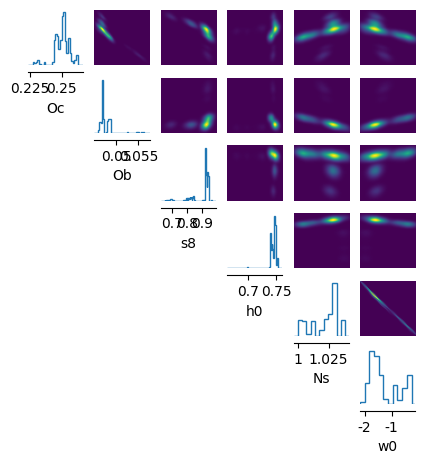

In [27]:
gt_obs = gt[42,:]
print(gt_obs)
_ = pairplot(samples.cpu().numpy(), upper='kde', figsize=(5,5), labels=param_names)

Removed no burn in
Removed no burn in
Removed no burn in


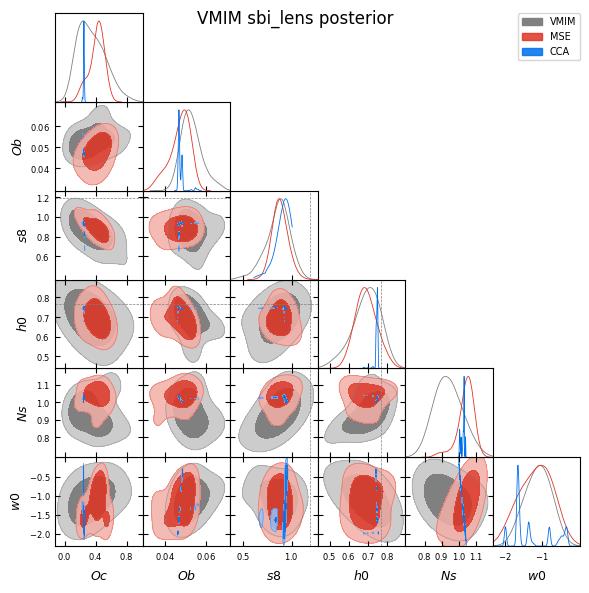

In [39]:
with open(f"posterior_samples/NLE_VMIM_posterior_{n_samples}samples.pkl", "rb") as f:
    vmim_samples = pickle.load(f)
with open(f"posterior_samples/NLE_MSE_posterior_{n_samples}samples.pkl", "rb") as f:
    mse_samples = pickle.load(f)
with open(f"posterior_samples/NLE_CCA_posterior_{n_samples}samples.pkl", "rb") as f:
    cca_samples = pickle.load(f)
    
g = plots.get_subplot_plotter(subplot_size=1)
# convert to numpy array (nsamples, nparams)
vmim_samples_np = vmim_samples.cpu().numpy()
mse_samples_np = mse_samples.cpu().numpy()
cca_samples_np = cca_samples.cpu().numpy()
# create a getdist MCSamples object with names/labels
vmim_mcs = MCSamples(
    samples=vmim_samples_np, 
    names=param_names, 
    labels=param_names,
    )
mse_mcs = MCSamples(
    samples=mse_samples_np, 
    names=param_names, 
    labels=param_names,
    )
cca_mcs = MCSamples(
    samples=cca_samples_np, 
    names=param_names, 
    labels=param_names,
    )
# pass the MCSamples (not a nested list of lists)
g.triangle_plot(
    [vmim_mcs, mse_mcs, cca_mcs], 
    filled=True, 
    legend_labels=["VMIM","MSE","CCA"],
    legend_loc="upper right"
    )
g.add_param_markers(
        {param_names[0]: cd_obs[0].item(), 
        param_names[1]: cd_obs[1].item(), 
        param_names[2]: cd_obs[2].item(), 
        param_names[3]: cd_obs[3].item(), 
        param_names[4]: cd_obs[4].item(), 
        param_names[5]: cd_obs[5].item(), 
        }
    )
plt.suptitle("VMIM sbi_lens posterior")
plt.savefig("plots/posteriors/VMIM_posterior.pdf")
plt.show()
